<a href="https://colab.research.google.com/github/Zeeba1705/atml_PA0/blob/main/Task3_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TASK 3: Contrastive Learning and CLIP Model

###3.1: Zero-Shot Classification on STL-10

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_21ff_in
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_21ff_in
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=54cf068e690a70f916c8e65b12587ec2769864cda0979df1e09339725e0b7f67
  Stored in directory: /tmp/pip-ephem-wheel-cache-g0e3kcz0/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
import torch
import clip
import numpy as np

from torchvision.datasets import STL10
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
model, preproc = clip.load("ViT-B/32", device=device)

model.eval()

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 73.7MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [4]:
#torchvision.datasets.STL10(root: Union[str, Path], split: str = 'train', folds: Optional[int] = None, transform: Optional[Callable] = None,
 #                          target_transform: Optional[Callable] = None, download: bool = False)

test_data= STL10(root='./data', split='test', download=True, transform=preproc)

test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

100%|██████████| 2.64G/2.64G [1:21:55<00:00, 537kB/s]


In [5]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/data/stl10_binary /content/drive/MyDrive/

Mounted at /content/drive


In [6]:
print(test_data.classes) #just making sure which index corr to which class

['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [7]:
#need a function for the diff prompting techniques:
class_names= test_data.classes

def prompt_type(class_names, prompt_des):
  if prompt_des=="plain_label":
    prompt= list(class_names)

  elif prompt_des=="prompted_text":
    prompt=[f"a photo of a {class_name}" for class_name in class_names]

  elif prompt_des=="description":
    desc={
        "airplane": "a photo of an airplane flying",
        "bird": "a photo of a bird with wings",
        "car": "a photo of a car on the road",
        "cat": "a photo of a household cat",
        "deer": "a photo of a deer outdoors",
        "dog": "a photo of a domestic dog",
        "horse": "a photo of a horse in the field",
        "monkey": "a photo of a monkey outdoors",
        "ship": "a photo of a ship in the water",
        "truck": "a photo of a large truck on a road",
    }

    prompt=[desc[class_name] for class_name in class_names]

  return prompt




In [8]:
# time to prep the prompts for input to CLIP
def text_feat_prep(class_names, p_type):
  prompt= prompt_type(class_names, p_type)
  tokens= clip.tokenize(prompt).to(device)

  with torch.no_grad():
    text_features= model.encode_text(tokens)

  text_features= text_features.float()

  text_features /= text_features.norm(dim=-1, keepdim=True)

  return text_features



In [9]:

def image_prep(images):

  images= images.to(device)

  with torch.no_grad():
    image_features= model.encode_image(images)

  image_features= image_features.float()
  image_features /= image_features.norm(dim=-1, keepdim=True)

  return image_features


In [17]:
def evaluate_clip(text_features):

  num_correct=0
  total=0

  for images, labels in test_loader:
    labels= labels.to(device)

    image_feats= image_prep(images)

    similarity= image_feats @ text_features.T

    predictions= similarity.argmax(dim=1)

    num_correct+= (predictions==labels).sum().item()
    total+= labels.size(0)

  acc = num_correct/total

  return acc

In [15]:
plain_features = text_feat_prep(class_names,"plain_label")

prompted_features = text_feat_prep(class_names,"prompted_text")

description_features = text_feat_prep(class_names,"description")

In [18]:
plain_acc = evaluate_clip(plain_features)
prompted_acc = evaluate_clip(prompted_features)
description_acc = evaluate_clip(description_features)

print(f"Plain label accuracy: {plain_acc * 100:.2f}%")
print(f"Prompted text accuracy: {prompted_acc * 100:.2f}%")
print(f"Description accuracy: {description_acc * 100:.2f}%")

Plain label accuracy: 96.25%
Prompted text accuracy: 97.36%
Description accuracy: 94.79%


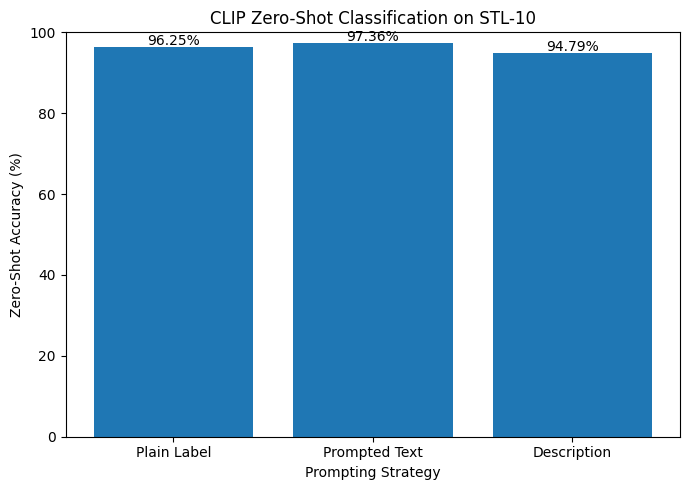

In [19]:
import matplotlib.pyplot as plt

strategies = ["Plain Label", "Prompted Text", "Description"]

accuracies = [
    plain_acc * 100,
    prompted_acc * 100,
    description_acc * 100
]

plt.figure(figsize=(7, 5))

bars = plt.bar(strategies, accuracies)

plt.ylabel("Zero-Shot Accuracy (%)")
plt.xlabel("Prompting Strategy")
plt.title("CLIP Zero-Shot Classification on STL-10")

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

###3.2: Exploring the Modality Gap

In [10]:
num_samples= 50

sample_images= []
sample_labels= []

for images, labels in test_loader:

    for image, label in zip(images, labels):

        sample_images.append(image)
        sample_labels.append(label)

        if len(sample_images)== num_samples:
            break

    if len(sample_images)== num_samples:
        break


sample_images= torch.stack(sample_images)
sample_labels= torch.tensor(sample_labels)


print("Images:", sample_images.shape)
print("Labels:", sample_labels.shape)

Images: torch.Size([50, 3, 224, 224])
Labels: torch.Size([50])


In [11]:
sample_names= [class_names[label.item()] for label in sample_labels]

sample_prompts= [f"a photo of a {name}" for name in sample_names]

In [12]:
def get_raw_image_features(images):

    images= images.to(device)

    with torch.no_grad():
        features= model.encode_image(images)

    return features.float()



In [13]:
def get_raw_text_features(prompts):

    tokens= clip.tokenize(prompts).to(device)

    with torch.no_grad():
        features = model.encode_text(tokens)

    return features.float()



In [14]:
#so that i can compare effect of normalisation on modality gap later

raw_image_features = get_raw_image_features(sample_images)
raw_text_features = get_raw_text_features(sample_prompts)

norm_img_feats= raw_image_features / raw_image_features.norm(dim=-1, keepdim=True)
norm_text_feats= raw_text_features / raw_text_features.norm(dim=-1, keepdim=True)


In [15]:
#Time to use t-sne
from sklearn.manifold import TSNE

rcomb_feats= torch.cat([raw_image_features, raw_text_features], dim=0).cpu().numpy() #combining brcause we need image and text features in the same 2-D space

tsne_raw = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

raw_2d= tsne_raw.fit_transform(rcomb_feats)

raw_image_2d= raw_2d[:num_samples]
raw_text_2d= raw_2d[num_samples:]



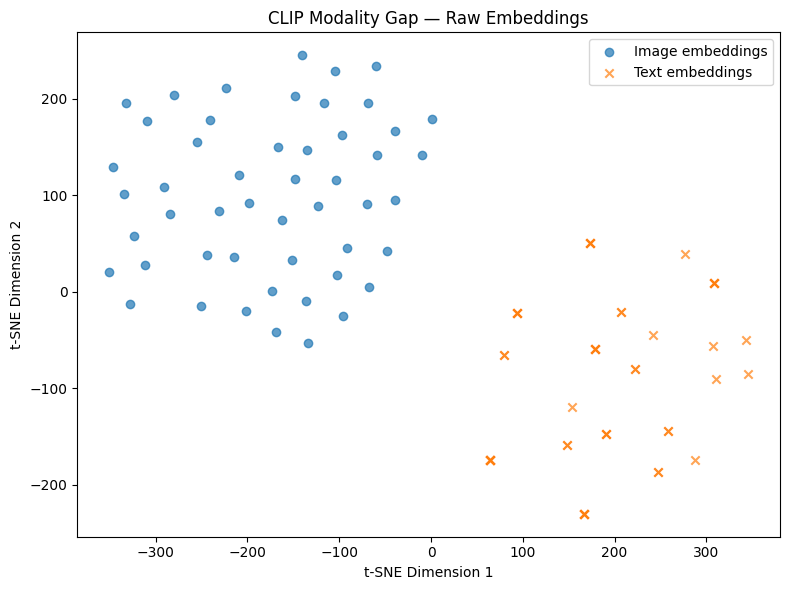

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    raw_image_2d[:, 0],
    raw_image_2d[:, 1],
    label="Image embeddings",
    alpha=0.7
)

plt.scatter(
    raw_text_2d[:, 0],
    raw_text_2d[:, 1],
    label="Text embeddings",
    marker="x",
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title(
    "CLIP Modality Gap — Raw Embeddings"
)
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
ncomb_feats= torch.cat([norm_img_feats, norm_text_feats], dim=0).cpu().numpy() #combining brcause we need image and text features in the same 2-D space

tsne_norm= TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

norm_2d= tsne_norm.fit_transform(ncomb_feats)

norm_image_2d= norm_2d[:num_samples]
norm_text_2d= norm_2d[num_samples:]

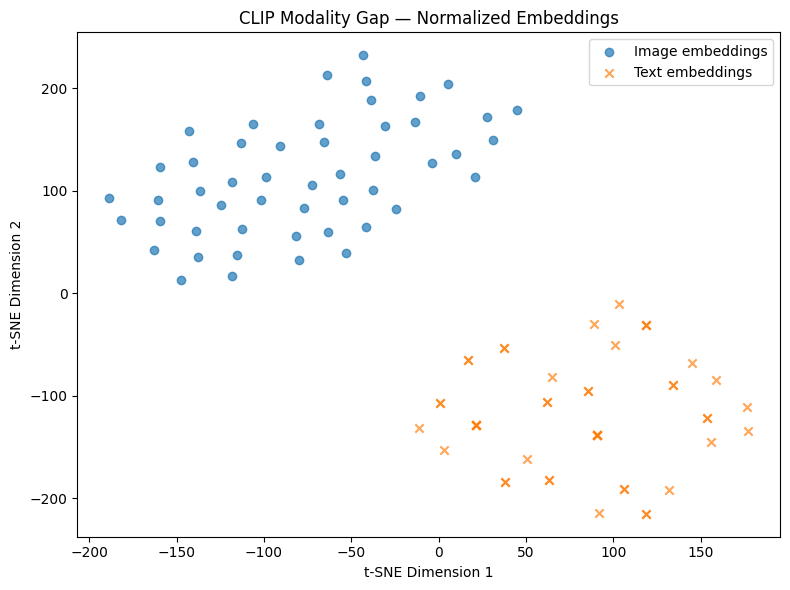

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    norm_image_2d[:, 0],
    norm_image_2d[:, 1],
    label="Image embeddings",
    alpha=0.7
)

plt.scatter(
    norm_text_2d[:, 0],
    norm_text_2d[:, 1],
    label="Text embeddings",
    marker="x",
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title(
    "CLIP Modality Gap — Normalized Embeddings"
)
plt.legend()

plt.tight_layout()
plt.show()


In [29]:
image_norms= raw_image_features.norm(dim=1).cpu().numpy()

text_norms= raw_text_features.norm(dim=1).cpu().numpy()

print("Mean image norm:",image_norms.mean())

print("Mean text norm:",text_norms.mean())

Mean image norm: 10.560054
Mean text norm: 10.144258


###3.3: Bridging the Modality Gap

In [17]:
X= norm_img_feats.cpu().numpy()
Y= norm_text_feats.cpu().numpy()

print(X.shape)
print(Y.shape)

(50, 512)
(50, 512)


In [18]:
from scipy.linalg import orthogonal_procrustes

R, scale = orthogonal_procrustes(X, Y)

#transforming x using r
transf_x= X @ R

before_err= np.linalg.norm(X - Y, ord="fro")
after_err = np.linalg.norm(transf_x - Y,ord="fro")

print("Frobenius error before alignment:", before_err)
print("Frobenius error after alignment:", after_err)

Frobenius error before alignment: 8.56931
Frobenius error after alignment: 3.416404


In [19]:
aligned_combined = np.concatenate([transf_x, Y], axis=0)

tsne_aligned= TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

aligned_2d = tsne_aligned.fit_transform(aligned_combined)

aligned_image_2d= aligned_2d[:num_samples]
aligned_text_2d= aligned_2d[num_samples:]

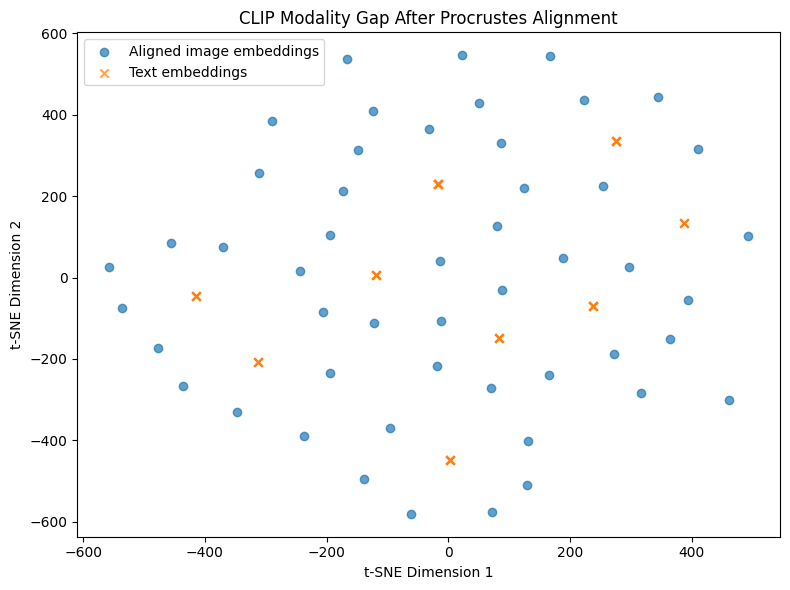

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    aligned_image_2d[:, 0],
    aligned_image_2d[:, 1],
    label="Aligned image embeddings",
    alpha=0.7
)

plt.scatter(
    aligned_text_2d[:, 0],
    aligned_text_2d[:, 1],
    label="Text embeddings",
    marker="x",
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("CLIP Modality Gap After Procrustes Alignment")

plt.legend()
plt.tight_layout()
plt.show()

In [22]:
R_tensor = torch.tensor(R, dtype=torch.float32, device=device)

prompted_feats= text_feat_prep(class_names, "prompted_text")

In [23]:
def evaluate_aligned_clip(text_feats, R_tensor):

    num_correct= 0
    total= 0

    with torch.no_grad():

        for i, (images, labels) in enumerate(test_loader):

            labels= labels.to(device)

            image_feats = image_prep(images)

            aligned_image_feats = image_feats @ R_tensor

            similarity = aligned_image_feats @ text_feats.T

            predictions= similarity.argmax(dim=1)

            num_correct += (predictions == labels).sum().item()

            total+= labels.size(0)

            if (i + 1) % 10 == 0:
                print(
                    f"Completed {i + 1}/{len(test_loader)} batches"
                )

    return num_correct / total

In [24]:
aligned_acc= evaluate_aligned_clip(prompted_feats,R_tensor)

print(f"Original prompted-text accuracy: {97.36:.2f}%")

print(f"Aligned accuracy: {aligned_acc * 100:.2f}%")

Completed 10/125 batches
Completed 20/125 batches
Completed 30/125 batches
Completed 40/125 batches
Completed 50/125 batches
Completed 60/125 batches
Completed 70/125 batches
Completed 80/125 batches
Completed 90/125 batches
Completed 100/125 batches
Completed 110/125 batches
Completed 120/125 batches
Original prompted-text accuracy: 97.36%
Aligned accuracy: 86.44%


In [25]:
print("X:", X.shape)
print("Y:", Y.shape)

print("Unique text embeddings:",
      np.unique(np.round(Y, decimals=6), axis=0).shape[0])

X: (50, 512)
Y: (50, 512)
Unique text embeddings: 9
